In [1]:
# # Insurance Risk Analytics - Exploratory Data Analysis
#
# ## Objective
# Analyze insurance claims and premium data to identify:
# - Risk patterns
# - Profitability drivers
# - Geographic trends
# - Claim behavior
# - Outliers and anomalies
#
# ## Author
# Elda Girma
#
# ## Task
# Task 1 - Exploratory Data Analysis

In [2]:
# Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Data Handling
import pandas as pd
import numpy as np

#Visualuzation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Notebook Settings
pd.set_option("display.max_columns", None)

#Import custom utility
from src.data_loader import load_data

In [3]:
#Load dataset

df = load_data("../data/MachineLearningRating_v3.txt")

#Preview data
print(df.head())

   UnderwrittenCoverID  PolicyID     TransactionMonth  IsVATRegistered  \
0               145249     12827  2015-03-01 00:00:00             True   
1               145249     12827  2015-05-01 00:00:00             True   
2               145249     12827  2015-07-01 00:00:00             True   
3               145255     12827  2015-05-01 00:00:00             True   
4               145255     12827  2015-07-01 00:00:00             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
2              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
4              Close Corporation    Mr  English  First National Bank   

       AccountType  MaritalStatus         Gender       Country Province  \
0  Current account  Not specified  Not specifie

In [4]:
print(df.shape)

df.info()

(1000098, 52)
<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                

In [ ]:
# # Data Quality Assessment
#
# This section evaluates the quality of the dataset by identifying:
# - Missing values
# - Duplicate records
# - Data consistency issues
# - Potentially problematic features

In [6]:
#Missing values summary
missing_values = df.isnull().sum()

#Percentage of missing values
missing_percentage = (missing_values / len(df)) *100

#Combine into a dataframe
missing_df = pd.DataFrame({
    "Missing Values" : missing_values,
    "Percentage" : missing_percentage
})

#Sort descending
missing_df = missing_df.sort_values(
    by="Percentage",
    ascending=False
)

#Display only columns with missing values
print(missing_df[missing_df["Missing Values"] > 0])

                         Missing Values  Percentage
NumberOfVehiclesInFleet         1000098  100.000000
CrossBorder                      999400   99.930207
CustomValueEstimate              779642   77.956560
Rebuilt                          641901   64.183810
Converted                        641901   64.183810
WrittenOff                       641901   64.183810
NewVehicle                       153295   15.327998
Bank                             145961   14.594670
AccountType                       40232    4.022806
Gender                             9536    0.953507
MaritalStatus                      8259    0.825819
VehicleType                         552    0.055195
make                                552    0.055195
mmcode                              552    0.055195
Model                               552    0.055195
Cylinders                           552    0.055195
bodytype                            552    0.055195
kilowatts                           552    0.055195
NumberOfDoor

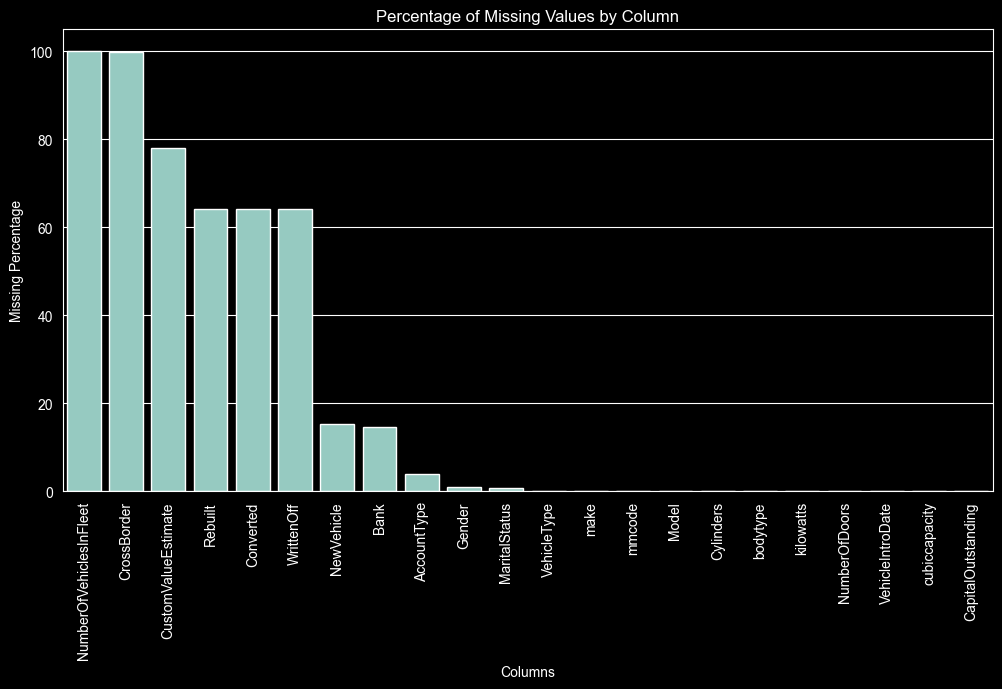

In [7]:
# Plot missing values percentage

plt.figure(figsize=(12, 6))

missing_df_filtered = missing_df[
    missing_df["Percentage"] > 0
]

sns.barplot(
    x=missing_df_filtered.index,
    y=missing_df_filtered["Percentage"]
)

plt.xticks(rotation=90)
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")

plt.show()

In [8]:
# Check duplicates
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [9]:
# Unique policies
print("Unique Policy IDs:", df["PolicyID"].nunique())

# Unique cover IDs
print("Unique Underwritten Cover IDs:",
      df["UnderwrittenCoverID"].nunique())

Unique Policy IDs: 7000
Unique Underwritten Cover IDs: 116532


In [10]:
# Convert date columns
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"],
    errors="coerce"
)

df["VehicleIntroDate"] = pd.to_datetime(
    df["VehicleIntroDate"],
    format="%m/%Y",
    errors="coerce"
)

# Verify
df[["TransactionMonth",
    "VehicleIntroDate"]].dtypes

TransactionMonth    datetime64[us]
VehicleIntroDate    datetime64[us]
dtype: object

In [11]:
# Numerical columns
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

print("Number of Numerical Columns:",
      len(numerical_cols))

print("Number of Categorical Columns:",
      len(categorical_cols))

Number of Numerical Columns: 15
Number of Categorical Columns: 34


In [ ]:
# ## Data Quality Observations
#
# The dataset contains 1,000,098 records and 52 features, with varying levels of missing data across several variables.
#
# Key findings from the missing-value assessment include:
#
# - `NumberOfVehiclesInFleet` contains 100% missing values and provides no analytical value in its current form. This feature may be removed in later modeling stages.
# - `CrossBorder` contains approximately 99.93% missing values, making it unsuitable for reliable analysis without substantial imputation assumptions.
# - `CustomValueEstimate` has approximately 77.96% missing values, which may limit its usefulness for predictive modeling unless carefully imputed.
# - `WrittenOff`, `Rebuilt`, and `Converted` each contain more than 64% missing values, suggesting sparse reporting or limited applicability across policies.
# - `NewVehicle` and `Bank` also contain notable missingness (15.33% and 14.59% respectively).
# - Most remaining variables contain minimal missing values, indicating generally strong data completeness across core insurance, geographic, and premium-related features.
#
# Duplicate analysis revealed:
# - No fully duplicated rows were detected in the dataset.
# - The dataset contains 7,000 unique policies and 116,532 unique underwritten cover IDs, indicating that the data is recorded at a detailed transactional and coverage level rather than a single-row-per-policy level.
#
# Date conversion was successfully completed for:
# - `TransactionMonth`
# - `VehicleIntroDate`
#
# These conversions enable future temporal trend analysis and feature engineering.
#
# At this stage, no rows or columns are removed. Missing-value handling strategies will be addressed more carefully during modeling and feature engineering phases.